<a href="https://colab.research.google.com/github/Cassio295/Cassio295/blob/master/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pathlib
import pandas as pd
path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')
arquivo = pathlib.Path(path + '/heart.csv')
dataset = pd.read_csv(arquivo, sep = ',')

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


Descrição das colunas
- 1.Age
- 2.Sex M: Male F: Femele
- 3.CheastPainType: (TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic)
- 4.RestingBP resting blood presurre [mm HG]
- 5.Cholesterol: Serum Cholesterol
- 6.FastingBS fasting blood sugar: [1 if FastingBS > 120 mg/dl, 0 otherwise]
- 7.RestingECG: Resting electrocadiogram results [Normal: Normal, ST: ST-T wave abnormality (T wave inversion and/or ST elevation or depresion of > 0.05 mv, LVH: showing probable or definite left ventricular hypertrophy by Ester)]
- 8.MaxHR: Maximum heart rate achieved [numeric value between 60 and 202]
- 9.ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
- 10.Oldpeak: oldpeak = ST [numeric value measured in depression]
- 11.ST_Slope: the slope os the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
-12. HeartDisease: Output class [1: heart disease, 0: Normal]


Objetivo fazer dois modelos de classificação tanto um simples quanto uma rede neural podendo ambos ser complexos ou não

Começando a análise exploratoria

In [ ]:
dataset.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
dataset.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
len(dataset)

918

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
objetos = dataset.select_dtypes('object')

In [ ]:
dataset['count'] = 1

In [ ]:
dataset['Age'].unique()

array([40, 49, 37, 48, 54, 39, 45, 58, 42, 38, 43, 60, 36, 44, 53, 52, 51,
       56, 41, 32, 65, 35, 59, 50, 47, 31, 46, 57, 55, 63, 66, 34, 33, 61,
       29, 62, 28, 30, 74, 68, 72, 64, 69, 67, 73, 70, 77, 75, 76, 71])

In [ ]:
# Plotando alguns gráficos para entender melhor os dados
import plotly.express as px
total_pacientes = dataset['count'].sum()
fig = px.bar(dataset[['Sex', 'ChestPainType', 'count','HeartDisease']].groupby(['Sex','ChestPainType', 'HeartDisease']).sum().reset_index(),
             x = 'Sex',
             y = 'count',
             facet_col='ChestPainType',
             color='HeartDisease',
             title= 'Tipo de Dor no Peito Por Sexo'
             )
fig.show()


In [ ]:
fig1 = px.bar(
    dataset[['Age', 'Sex', 'HeartDisease','count', 'ChestPainType']].groupby(['Age', 'Sex', 'HeartDisease', 'ChestPainType']).sum().reset_index(),
    x = 'ChestPainType',
    y= 'count',
    color='Age',
    facet_col='HeartDisease'
)
fig1.show()

In [ ]:
objetos

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [ ]:
dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,count
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,1
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1,1


In [ ]:
colunas_object = objetos.columns

In [ ]:
colunas_object

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [ ]:
# Transformando as colunas do tipo object em inteiro para tirar a correlação entre os dados
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
l_encoder = LabelEncoder() #Vou usar o LabelEncoder porque as colunas do tipo object com exceção da coluna Sex todas tem mais de um dois valores distintos por isso optei pelo LabelEncoder


encoders = {} #Dicionario para acessar os encoders caso eu queira fazer a transformação inversa

for coluna in colunas_object:
    l_encoder.fit(objetos[coluna])
    encoders[coluna] = l_encoder
    dataset[coluna +'_encoded'] = l_encoder.fit_transform(dataset[coluna])


In [ ]:
# Dropando as colunas do tipo object
dataset.drop(colunas_object, axis=1, inplace = True)
dataset.drop('count', axis=1, inplace =True)

<Axes: >

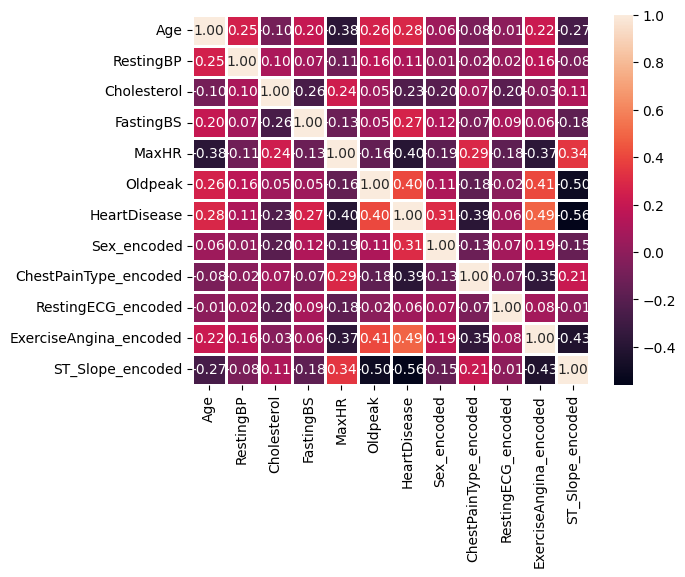

In [ ]:
import seaborn as sns
sns.heatmap(dataset.corr(), annot=True, linewidths=1, fmt= '.2f')

In [ ]:
dataset

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_encoded,ChestPainType_encoded,RestingECG_encoded,ExerciseAngina_encoded,ST_Slope_encoded
0,40,140,289,0,172,0.0,0,1,1,1,0,2
1,49,160,180,0,156,1.0,1,0,2,1,0,1
2,37,130,283,0,98,0.0,0,1,1,2,0,2
3,48,138,214,0,108,1.5,1,0,0,1,1,1
4,54,150,195,0,122,0.0,0,1,2,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,1,3,1,0,1
914,68,144,193,1,141,3.4,1,1,0,1,0,1
915,57,130,131,0,115,1.2,1,1,0,1,1,1
916,57,130,236,0,174,0.0,1,0,1,0,0,1


In [ ]:
# Separando em treino e teste
from sklearn.model_selection import train_test_split
x =dataset.drop('HeartDisease',axis=1).values
y = dataset['HeartDisease'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Para classificação vou usar os modelos de classificação Naive Bayes, arvore de decisão e floresta aleatoria
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble._forest import RandomForestClassifier

gaussian = GaussianNB()
tree = DecisionTreeClassifier()
random = RandomForestClassifier(n_estimators=100)

gaussian.fit(x_train, y_train)
tree.fit(x_train, y_train)
random.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
y_predic_gau = gaussian.predict(x_test)
y_predic_tree = tree.predict(x_test)
y_predic_random = random.predict(x_test)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
# GaussianNB
gau_score = precision_score(y_test, y_predic_gau)
gau_recall = recall_score(y_test, y_predic_gau)
gau_f_1score = f1_score(y_test, y_predic_gau)

# Decision Tree
tree_score = precision_score(y_test, y_predic_tree)
tree_recall = recall_score(y_test, y_predic_tree)
tree_f_1score = f1_score(y_test, y_predic_tree)

# Random Forest
random_score = precision_score(y_test, y_predic_random)
random_recall = recall_score(y_test, y_predic_random)
random_f_1score = f1_score(y_test, y_predic_random)

print('GaussianNB')
print(f'Precisão: {gau_score}')
print(f'Recall: {gau_recall}')
print(f'F1 Score: {gau_f_1score}')

print('_' * 40)
print()

print('Decision Tree')
print(f'Precisão: {tree_score}')
print(f'Recall: {tree_recall}')
print(f'F1 Score: {tree_f_1score}')

print('_' * 40)
print()
print('Random Forest')
print(f'Precisão: {random_score}')
print(f'Recall: {random_recall}')
print(f'F1 Score: {random_f_1score}')

GaussianNB
Precisão: 0.8823529411764706
Recall: 0.8411214953271028
F1 Score: 0.861244019138756
________________________________________

Decision Tree
Precisão: 0.8723404255319149
Recall: 0.7663551401869159
F1 Score: 0.8159203980099502
________________________________________

Random Forest
Precisão: 0.9047619047619048
Recall: 0.8878504672897196
F1 Score: 0.8962264150943396


In [ ]:
# Agora usando o grid search CV
from sklearn.model_selection import GridSearchCV
decision_params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'min_samples_split': [2,4,6,8,10,12],
    'min_samples_leaf': [1,2,3,4,5,6]
}

random_params = {
    'n_estimators': [50,70,100,120,140,160,180,200,220],
    'min_samples_split': [2,4,6,8,10,12],
    'min_samples_leaf': [1,2,3,4,5,6,8],
    'criterion': ['gini','entropy', 'log_loss']
}

grid_tree = GridSearchCV(tree, param_grid= decision_params, cv=4, verbose=2 )

grid_random = GridSearchCV(random, param_grid= random_params, cv=4, verbose=2 )

grid_random.fit(x_train, y_train)
grid_tree.fit(x_train, y_train)


A saída de streaming foi truncada nas últimas 5000 linhas.
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=70; total time=   0.2s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=70; total time=   0.1s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=70; total time=   0.1s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=100; total time=   0.3s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=100; total time=   0.2s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=120; total time=   0.3s
[CV] END criterion=gini, min_samples_leaf=2, min_samples_split=12, n_estimators=120; total time=   0.3s
[CV] END

GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6],
                         'min_samples_split': [2, 4, 6, 8, 10, 12],
                         'splitter': ['best', 'random']},
             verbose=2)

In [ ]:
# Agora vamos avaliar os melhores parametros para os modelos]
from sklearn.metrics import classification_report
y_pred_tree_grid = grid_tree.best_estimator_.predict(x_test)
y_pred_random_grid = grid_random.best_estimator_.predict(x_test)

print('Decision Tree')
print(classification_report(y_test, y_pred_tree_grid))
print()
print('(っ °Д °;)っ' * 10)

print('Random Forest')
print(classification_report(y_test, y_pred_random_grid))
print()
print('(っ °Д °;)っ' * 10)
print('Gaussian NB')
print(classification_report(y_test, y_predic_gau))


Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.78      0.75        77
           1       0.83      0.79      0.81       107

    accuracy                           0.79       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.79      0.79       184


(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ
Random Forest
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        77
           1       0.91      0.90      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184


(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ(っ °Д °;)っ
Gaussian NB
              precision    recall  f1-score   support

           0       0.79      0.84      0.82    

In [ ]:
y_train.shape

(734,)

In [ ]:
# Começando a montar uma rede neural para classificação
import tensorflow
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

model = tensorflow.keras.models.Sequential(name = 'Sono1')
model.add(tensorflow.keras.layers.Input(shape=(11,)))
model.add(tensorflow.keras.layers.Dense(16, activation='relu'))
model.add(tensorflow.keras.layers.Dense(10, activation = 'relu'))
model.add(tensorflow.keras.layers.Dense(1, activation = 'sigmoid'))
model.compile(optimizer= 'Adam', loss='binary_crossentropy', metrics=['Recall', 'Precision'])

re = ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.002,
    patience = 2,
    # min_lr =1e-6,
    verbose = 1
)
early = EarlyStopping(
    monitor = 'val_Recall',
    patience = 5,
    verbose = 1
)

model.fit(x_train, y_train, batch_size=32, epochs=100, validation_split=0.5, callbacks= re )
precision, recall, loss = model.evaluate(x_test, y_test)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - Precision: 0.5852 - Recall: 1.0000 - loss: 27.0616 - val_Precision: 0.5085 - val_Recall: 0.9424 - val_loss: 13.0366 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - Precision: 0.5669 - Recall: 0.7446 - loss: 9.8439 - val_Precision: 0.6336 - val_Recall: 0.4346 - val_loss: 8.3834 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Precision: 0.5428 - Recall: 0.4142 - loss: 10.1547 - val_Precision: 0.5197 - val_Recall: 0.6230 - val_loss: 6.5284 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Precision: 0.5560 - Recall: 0.6691 - loss: 6.9847 - val_Precision: 0.5018 - val_Recall: 0.7487 - val_loss: 6.6045 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - Precision: 0.5149 - Recall: 0.6221 - loss: 7.5932 - val_Precision: 0.5154 - val_Recall: 0.6126 - val_loss: 5.3604 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━

Text(0.5, 1.0, 'Precição')

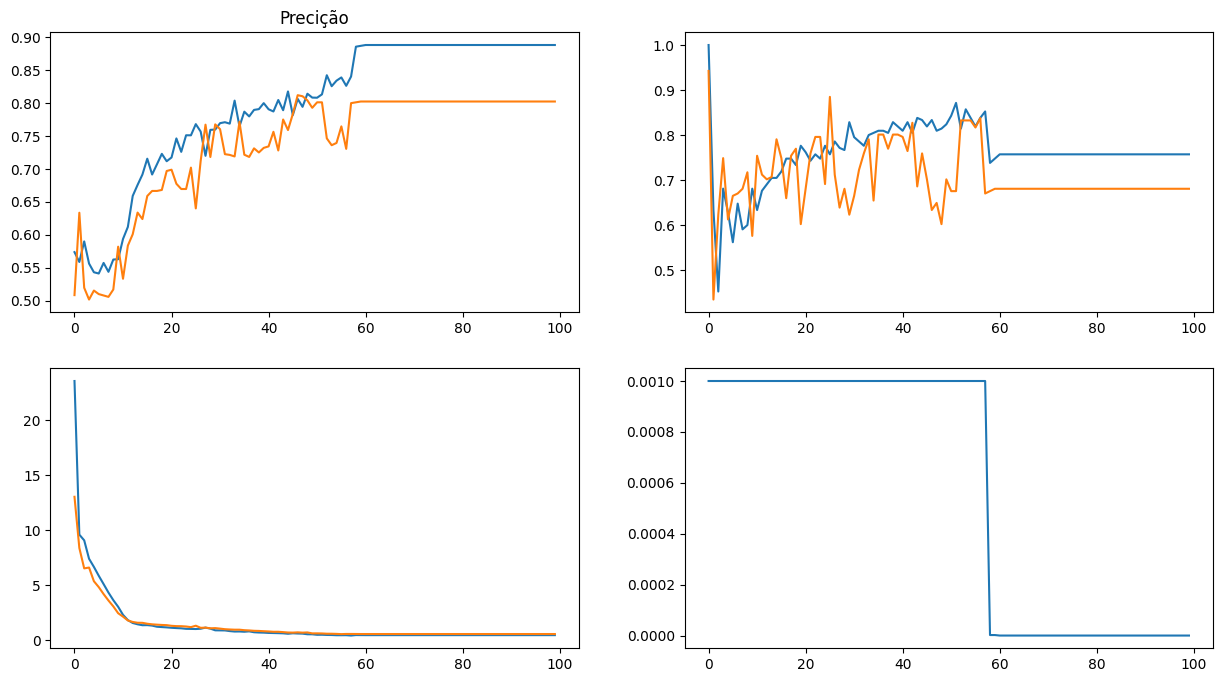

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,2, figsize=(15,8))
ax[0][0].plot(model.history.history['Precision'], label = 'Precisão')
ax[0][0].plot(model.history.history['val_Precision'], label='val_precision')

ax[0][1].plot(model.history.history['Recall'], label ='Recall')
ax[0][1].plot(model.history.history['val_Recall'], label = 'val_recall')

ax[1][0].plot(model.history.history['loss'], label ='loss')
ax[1][0].plot(model.history.history['val_loss'], label='val_loss')

ax[1][1].plot(model.history.history['learning_rate'], label='learning rate')

ax[0][0].set_title('Precição')
